In [151]:
import fastf1
import pandas as pd

# fastf1.Cache.enable_cache('./cache')

#### Pull session data

In [152]:
years = [2022, 2023, 2024, 2025]

all_races = {}
for year in years:
    schedule = fastf1.get_event_schedule(year)
    races = list(schedule['EventName'].unique())
    all_races[year] = races

print(all_races)

{2022: ['Pre-Season Track Session', 'Pre-Season Test', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix', 'Emilia Romagna Grand Prix', 'Miami Grand Prix', 'Spanish Grand Prix', 'Monaco Grand Prix', 'Azerbaijan Grand Prix', 'Canadian Grand Prix', 'British Grand Prix', 'Austrian Grand Prix', 'French Grand Prix', 'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix', 'Italian Grand Prix', 'Singapore Grand Prix', 'Japanese Grand Prix', 'United States Grand Prix', 'Mexico City Grand Prix', 'São Paulo Grand Prix', 'Abu Dhabi Grand Prix'], 2023: ['Pre-Season Testing', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix', 'Azerbaijan Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix', 'Spanish Grand Prix', 'Canadian Grand Prix', 'Austrian Grand Prix', 'British Grand Prix', 'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix', 'Italian Grand Prix', 'Singapore Grand Prix', 'Japanese Grand Prix', 'Qatar Grand Prix', 'United Sta

#### Grand Prix Races that include 2025

In [153]:
list_of_races = ["Australian Grand Prix", "Chinese Grand Prix", "Japanese Grand Prix", "Bahrain Grand Prix", "Saudi Arabian Grand Prix"]

In [199]:
all_laps = []
failed_races = []
sessions = []

for year in years:
    # schedule = fastf1.get_event_schedule(year)
    # # Filter to only Grand Prix races (ignore test, pre-season, etc.)
    # gp_schedule = schedule[schedule['EventName'].str.contains('Grand Prix', case=False)].copy()
    
    # # For 2025, filter to events before June 1, 2025
    # if year == 2025:
    #     gp_schedule['EventDate'] = pd.to_datetime(gp_schedule['EventDate'])
    #     gp_schedule = gp_schedule[gp_schedule['EventDate'] <= '2025-06-01']

    session = fastf1.get_session(year, 'Spanish Grand Prix', 'R')
    session.load(laps=True, weather=True, telemetry=True)
    sessions.append(session)

    if hasattr(session, 'laps') and len(session.laps) > 0:
        df = session.laps.copy()
        df['Year'] = year
        df['Race'] = 'Spanish Grand Prix'
        all_laps.append(df)
    
    # for _, row in gp_schedule.iterrows():
    #     race_name = row['EventName']
    #     try:
    #         session = fastf1.get_session(year, race_name, 'R')
    #         session.load(laps=True, weather=True, telemetry=True)
    #         sessions.append(session)
    #         if hasattr(session, 'laps') and len(session.laps) > 0:
    #             df = session.laps.copy()
    #             df['Year'] = year
    #             df['Race'] = race_name
    #             all_laps.append(df)
    #         else:
    #             failed_races.append((year, race_name))
    #     except Exception as e:
    #         failed_races.append((year, race_name))

# if all_laps:
#     laps_df = pd.concat(all_laps, ignore_index=True)
#     print(f"Total laps loaded: {len(laps_df)}")
# else:
#     print("No lap data loaded.")

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '63', '55', '44', '77', '31', '4', '14', '22', '5', '3', '10', '47', '18', '6', '20', '23', '24', '16']
core           INFO 	Loading data for Spanish Grand Prix - Race

In [200]:
laps_df = pd.concat(all_laps, ignore_index=True)
laps_df

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Year,Race
0,0 days 01:03:42.883000,VER,1,0 days 00:01:29.739000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.819000,...,0 days 01:02:12.915000,2022-05-22 13:03:12.928,12,2.0,False,,False,False,2022,Spanish Grand Prix
1,0 days 01:05:10.392000,VER,1,0 days 00:01:27.509000,2.0,1.0,NaT,NaT,0 days 00:00:24.345000,0 days 00:00:33.238000,...,0 days 01:03:42.883000,2022-05-22 13:04:42.896,1,2.0,False,,False,True,2022,Spanish Grand Prix
2,0 days 01:06:37.966000,VER,1,0 days 00:01:27.574000,3.0,1.0,NaT,NaT,0 days 00:00:24.494000,0 days 00:00:33.214000,...,0 days 01:05:10.392000,2022-05-22 13:06:10.405,1,2.0,False,,False,True,2022,Spanish Grand Prix
3,0 days 01:08:05.567000,VER,1,0 days 00:01:27.601000,4.0,1.0,NaT,NaT,0 days 00:00:24.462000,0 days 00:00:33.042000,...,0 days 01:06:37.966000,2022-05-22 13:07:37.979,1,2.0,False,,False,True,2022,Spanish Grand Prix
4,0 days 01:09:33.504000,VER,1,0 days 00:01:27.937000,5.0,1.0,NaT,NaT,0 days 00:00:24.486000,0 days 00:00:33.222000,...,0 days 01:08:05.567000,2022-05-22 13:09:05.580,1,2.0,False,,False,True,2022,Spanish Grand Prix
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5050,0 days 02:27:19.124000,BEA,87,0 days 00:01:20.255000,62.0,4.0,NaT,NaT,0 days 00:00:23.593000,0 days 00:00:32.490000,...,0 days 02:25:58.869000,2025-06-01 14:30:03.067,1,14.0,False,,False,True,2025,Spanish Grand Prix
5051,0 days 02:28:38.031000,BEA,87,0 days 00:01:18.907000,63.0,4.0,NaT,NaT,0 days 00:00:22.884000,0 days 00:00:32.034000,...,0 days 02:27:19.124000,2025-06-01 14:31:23.322,1,13.0,False,,False,True,2025,Spanish Grand Prix
5052,0 days 02:29:58.331000,BEA,87,0 days 00:01:20.300000,64.0,4.0,NaT,NaT,0 days 00:00:23.498000,0 days 00:00:32.736000,...,0 days 02:28:38.031000,2025-06-01 14:32:42.229,1,13.0,False,,False,True,2025,Spanish Grand Prix
5053,0 days 02:31:18.413000,BEA,87,0 days 00:01:20.082000,65.0,4.0,NaT,NaT,0 days 00:00:23.363000,0 days 00:00:32.711000,...,0 days 02:29:58.331000,2025-06-01 14:34:02.529,1,13.0,False,,False,True,2025,Spanish Grand Prix


In [201]:
laps_df.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race'],
      dtype='object')

In [202]:
laps_df['Year'].value_counts()

Year
2023    1312
2024    1310
2022    1230
2025    1203
Name: count, dtype: int64

#### Add weather and telemetry data

In [203]:
def enrich_with_weather(laps_df, sessions):
    enriched = []

    for session in sessions:
        weather_df = session.weather_data.copy()
        weather_df['Time'] = pd.to_timedelta(weather_df['Time'])  # ensure proper type

        # Match weather per lap
        session_laps = laps_df[
            (laps_df['Year'] == session.date.year) &
            (laps_df['Race'] == session.event['EventName'])
        ].copy()
        session_laps['Time'] = session_laps['LapStartTime'].dt.total_seconds()

        # Convert weather time to seconds to merge
        weather_df['WeatherTime'] = weather_df['Time'].dt.total_seconds()

        # Merge each lap with nearest weather row (on absolute time delta)
        session_laps = pd.merge_asof(
            session_laps.sort_values('Time'),
            weather_df.sort_values('WeatherTime'),
            left_on='Time',
            right_on='WeatherTime',
            direction='nearest',
            tolerance=60  # 1 minute
        )

        enriched.append(session_laps)

    return pd.concat(enriched, ignore_index=True)

In [204]:
weather_enriched_df = enrich_with_weather(laps_df, sessions)

In [205]:
weather_enriched_df.shape

(5055, 42)

In [206]:
weather_enriched_df.columns

Index(['Time_x', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'Time_y', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection',
       'WindSpeed', 'WeatherTime'],
      dtype='object')

In [207]:
def aggregate_telemetry(session, laps_df):
    all_features = []

    # Filter laps for this session year
    session_laps = laps_df[
        (laps_df['Year'] == session.date.year) &
        (laps_df['Race'] == session.event['EventName'])
    ]

    for _, lap_row in session_laps.iterrows():
        try:
            lap = session.laps[
                (session.laps['Driver'] == lap_row['Driver']) &
                (session.laps['LapNumber'] == lap_row['LapNumber'])
            ].iloc[0]

            telemetry = lap.get_car_data().add_distance()

            # Aggregate telemetry stats
            features = {
                'Driver': lap_row['Driver'],
                'LapNumber': lap_row['LapNumber'],
                'Stint': lap_row['Stint'],
                'Year': lap_row['Year'],
                'Race': lap_row['Race'],
                'Speed_Mean': telemetry['Speed'].mean(),
                'Speed_Max': telemetry['Speed'].max(),
                'Speed_Std': telemetry['Speed'].std(),
                'RPM_Mean': telemetry['RPM'].mean(),
                'Throttle_Mean': telemetry['Throttle'].mean(),
                'Throttle_Std': telemetry['Throttle'].std(),
                'Brake_Mean': telemetry['Brake'].mean(),
                'Gear_Mean': telemetry['nGear'].mean(),
                'Distance_Total': telemetry['Distance'].max(),  # for per-segment modelling
                'DRS_active_pct': telemetry['DRS'].mean() if 'DRS' in telemetry else 0
            }

            all_features.append(features)

        except (IndexError, AttributeError, KeyError):
            continue  # Skip if data missing

    return pd.DataFrame(all_features)

In [208]:
# Loop through each session and aggregate telemetry
telemetry_agg_dfs = []
for session in sessions:
    telemetry_agg_dfs.append(aggregate_telemetry(session, laps_df))
    print(f"Aggregated telemetry for {session.event['EventName']} {session.date.year}.")

# Combine telemetry features
telemetry_agg_df = pd.concat(telemetry_agg_dfs, ignore_index=True)

Aggregated telemetry for Spanish Grand Prix 2022.
Aggregated telemetry for Spanish Grand Prix 2023.
Aggregated telemetry for Spanish Grand Prix 2024.
Aggregated telemetry for Spanish Grand Prix 2025.


In [209]:
telemetry_agg_df.shape

(5055, 15)

In [210]:
telemetry_agg_df.columns

Index(['Driver', 'LapNumber', 'Stint', 'Year', 'Race', 'Speed_Mean',
       'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std',
       'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct'],
      dtype='object')

In [211]:
# Merge telemetry features into laps+weather
final_df = pd.merge(
    weather_enriched_df,
    telemetry_agg_df,
    on=['Driver', 'LapNumber', 'Stint', 'Year', 'Race'],
    how='inner'
)

In [212]:
# Check for duplicates
final_df.duplicated(subset=['Driver', 'LapNumber', 'Stint', 'Year', 'Race']).any()

False

In [213]:
# Save to csv for later use
final_df.to_csv('data/f1_laps_spanish.csv', index=False)

In [214]:
final_df.shape

(5055, 52)

In [215]:
final_df.columns

Index(['Time_x', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'Time_y', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection',
       'WindSpeed', 'WeatherTime', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct'],
      dtype='object')

#### Filter columns to keep

In [216]:
# Columns to keep
cols_to_keep = ['Driver', 'Team', 'Year', 'Race',
    'Stint', 'LapTime', 'LapNumber', 'Position',
    'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
    'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed',
    'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
    'Distance_Total', 'DRS_active_pct'
]

In [217]:
filtered_df = final_df[cols_to_keep]

In [218]:
filtered_df.shape

(5055, 29)

In [219]:
filtered_df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct'],
      dtype='object')

#### Filter rows to keep

In [220]:
filtered_df.isnull().sum()

Driver            0
Team              0
Year              0
Race              0
Stint             0
LapTime           1
LapNumber         0
Position          1
Compound          0
TyreLife          0
FreshTyre         0
TrackStatus       0
AirTemp           0
Humidity          0
Pressure          0
Rainfall          0
TrackTemp         0
WindDirection     0
WindSpeed         0
Speed_Mean        0
Speed_Max         0
Speed_Std         0
RPM_Mean          0
Throttle_Mean     0
Throttle_Std      0
Brake_Mean        0
Gear_Mean         0
Distance_Total    0
DRS_active_pct    0
dtype: int64

In [221]:
filtered_df[filtered_df['TyreLife'].isnull()].groupby(['Year', 'Race']).size()

Lap([], dtype: int64)

In [222]:
# filtered_df[(filtered_df['Year']==2025) & (filtered_df['Race']=='Miami Grand Prix')].shape

In [223]:
# # Remove 2025 Miami Grand Prix
# filtered_df = filtered_df[~((filtered_df['Year'] == 2025) & (filtered_df['Race'] == 'Miami Grand Prix'))]

In [224]:
filtered_df.isnull().sum()

Driver            0
Team              0
Year              0
Race              0
Stint             0
LapTime           1
LapNumber         0
Position          1
Compound          0
TyreLife          0
FreshTyre         0
TrackStatus       0
AirTemp           0
Humidity          0
Pressure          0
Rainfall          0
TrackTemp         0
WindDirection     0
WindSpeed         0
Speed_Mean        0
Speed_Max         0
Speed_Std         0
RPM_Mean          0
Throttle_Mean     0
Throttle_Std      0
Brake_Mean        0
Gear_Mean         0
Distance_Total    0
DRS_active_pct    0
dtype: int64

In [225]:
filtered_df[filtered_df['LapTime'].isnull()].groupby(['Year', 'Race']).size()

Year  Race              
2025  Spanish Grand Prix    1
dtype: int64

In [226]:
filtered_df[filtered_df['Position'].isnull()].groupby(['Year', 'Race']).size()

Year  Race              
2025  Spanish Grand Prix    1
dtype: int64

In [227]:
weather_cols = ['AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
filtered_df[filtered_df[weather_cols].isnull().any(axis=1)][['Driver', 'Race', 'Year', 'LapNumber'] + weather_cols].groupby(['Year', 'Race']).size()

Lap([], dtype: int64)

In [228]:
# mask = (
#     (filtered_df['Year'] == 2023) &
#     (filtered_df['Race'] == 'Italian Grand Prix') &
#     (filtered_df[weather_cols].isnull().any(axis=1))
# )

# filtered_df.loc[mask, ['Driver', 'LapNumber', 'TyreLife'] + weather_cols]

Filter out LapTime, Position, Weather data that are null after calculating LapsTilPit.

#### Calculate laps until pit

In [230]:
# Group by Year, Race, Driver, Stint and get min TyreLife per group
filtered_df.groupby(['Year', 'Race', 'Driver', 'Stint'])['TyreLife'].min().sort_values()

Year  Race                Driver  Stint
2022  Spanish Grand Prix  ALB     1.0       1.0
2024  Spanish Grand Prix  GAS     3.0       1.0
                          HAM     2.0       1.0
                          HUL     1.0       1.0
                                  2.0       1.0
                                           ... 
2022  Spanish Grand Prix  RIC     2.0       4.0
                          RUS     1.0       4.0
2025  Spanish Grand Prix  BEA     4.0       7.0
                          ALB     3.0      21.0
2023  Spanish Grand Prix  LEC     3.0      26.0
Name: TyreLife, Length: 271, dtype: float64

In [231]:
# Find races without a min TyreLife of 1
min_tyre_life = (
    filtered_df
    .groupby(['Year', 'Race', 'Driver', 'Stint'])['TyreLife']
    .min()
    .reset_index()
)

min_tyre_life[min_tyre_life['TyreLife'] != 1]

,Year,Race,Driver,Stint,TyreLife
4,2022,Spanish Grand Prix,ALB,5.0,4.0
8,2022,Spanish Grand Prix,ALO,4.0,3.0
9,2022,Spanish Grand Prix,BOT,1.0,4.0
14,2022,Spanish Grand Prix,GAS,3.0,4.0
15,2022,Spanish Grand Prix,GAS,4.0,4.0
...,...,...,...,...,...
253,2025,Spanish Grand Prix,RUS,1.0,4.0
256,2025,Spanish Grand Prix,RUS,4.0,4.0
265,2025,Spanish Grand Prix,TSU,5.0,4.0
266,2025,Spanish Grand Prix,VER,1.0,4.0


In [232]:
min_tyre_life[min_tyre_life['TyreLife'] != 1]['TyreLife'].value_counts()

TyreLife
4.0     78
3.0     10
2.0      9
26.0     1
21.0     1
7.0      1
Name: count, dtype: int64

These are all scrubbed tires that have been used in previous races.

In [233]:
# Grouping by Year, Race, Driver, Stint,
# LapsTilPit = max(TyreLife in stint) - TyreLife + 1
labelled_df = filtered_df.copy()

labelled_df['LapsTilPit'] = (
    filtered_df.groupby(['Year', 'Race', 'Driver', 'Stint'])['LapNumber']
    .transform(lambda x: x.max() - x + 1)
)

In [234]:
labelled_df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

In [235]:
# For a random stint, check LapsTilPit goes from max to 1
sample = labelled_df[
    (labelled_df['Driver'] == 'HAM') & 
    (labelled_df['Year'] == 2024) & 
    (labelled_df['Race'] == 'Spanish Grand Prix') & 
    (labelled_df['Stint'] == 1)]
print(sample[['LapNumber', 'TyreLife', 'LapsTilPit']])

      LapNumber  TyreLife  LapsTilPit
2554        1.0       4.0        16.0
2565        2.0       5.0        15.0
2585        3.0       6.0        14.0
2605        4.0       7.0        13.0
2625        5.0       8.0        12.0
2645        6.0       9.0        11.0
2665        7.0      10.0        10.0
2685        8.0      11.0         9.0
2705        9.0      12.0         8.0
2725       10.0      13.0         7.0
2745       11.0      14.0         6.0
2765       12.0      15.0         5.0
2785       13.0      16.0         4.0
2805       14.0      17.0         3.0
2825       15.0      18.0         2.0
2844       16.0      19.0         1.0


#### Visualize Label

In [236]:
import matplotlib.pyplot as plt

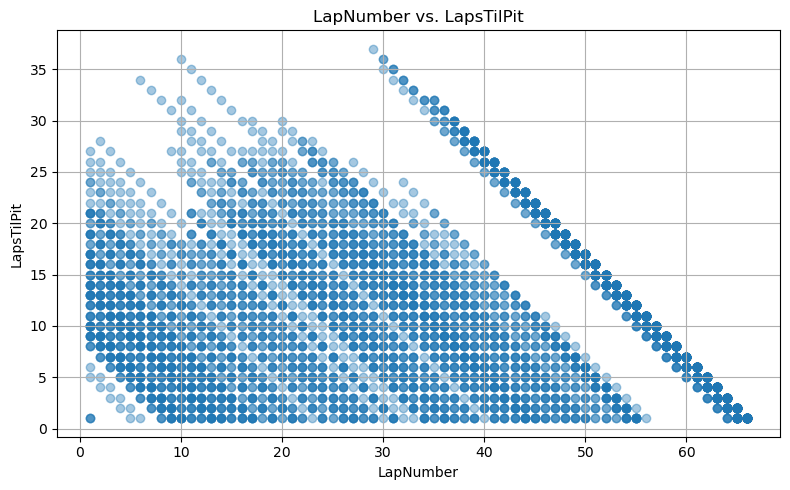

In [237]:
plt.figure(figsize=(8, 5))
plt.scatter(labelled_df['LapNumber'], labelled_df['LapsTilPit'], alpha=0.4)
plt.xlabel('LapNumber')
plt.ylabel('LapsTilPit')
plt.title('LapNumber vs. LapsTilPit')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

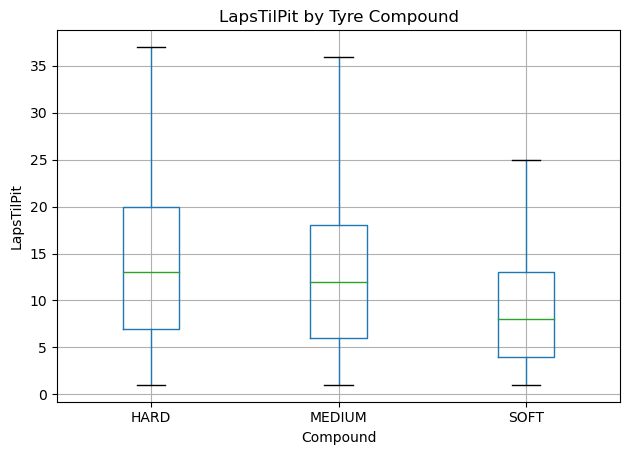

In [238]:
plt.figure(figsize=(8, 5))
labelled_df.boxplot(column='LapsTilPit', by='Compound')
plt.xlabel('Compound')
plt.ylabel('LapsTilPit')
plt.title('LapsTilPit by Tyre Compound')
plt.suptitle('')
plt.tight_layout()
plt.show()

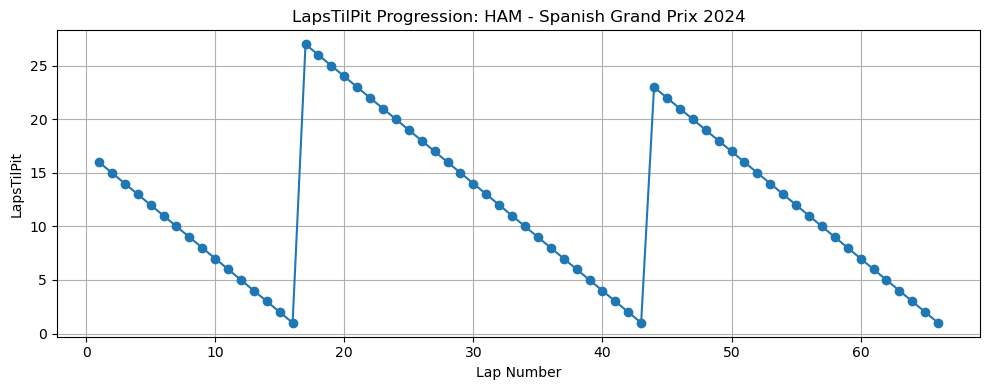

In [239]:
driver = 'HAM'
race = 'Spanish Grand Prix'
year = 2024

mask = (labelled_df['Driver'] == driver) & (labelled_df['Race'] == race) & (labelled_df['Year'] == year)
driver_race_df = labelled_df[mask].sort_values(['Stint', 'LapNumber'])

plt.figure(figsize=(10, 4))
plt.plot(driver_race_df['LapNumber'], driver_race_df['LapsTilPit'], marker='o')
plt.xlabel('Lap Number')
plt.ylabel('LapsTilPit')
plt.title(f'LapsTilPit Progression: {driver} - {race} {year}')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Remove Nulls

In [240]:
labelled_df.shape

(5055, 30)

In [241]:
labelled_df.isnull().sum()

Driver            0
Team              0
Year              0
Race              0
Stint             0
LapTime           1
LapNumber         0
Position          1
Compound          0
TyreLife          0
FreshTyre         0
TrackStatus       0
AirTemp           0
Humidity          0
Pressure          0
Rainfall          0
TrackTemp         0
WindDirection     0
WindSpeed         0
Speed_Mean        0
Speed_Max         0
Speed_Std         0
RPM_Mean          0
Throttle_Mean     0
Throttle_Std      0
Brake_Mean        0
Gear_Mean         0
Distance_Total    0
DRS_active_pct    0
LapsTilPit        0
dtype: int64

In [242]:
df_clean = labelled_df.dropna(subset=['LapTime'])

print(f"Shape before: {labelled_df.shape}")
print(f"Shape after:  {df_clean.shape}")

Shape before: (5055, 30)
Shape after:  (5054, 30)


In [243]:
df_clean.isnull().sum()

Driver            0
Team              0
Year              0
Race              0
Stint             0
LapTime           0
LapNumber         0
Position          0
Compound          0
TyreLife          0
FreshTyre         0
TrackStatus       0
AirTemp           0
Humidity          0
Pressure          0
Rainfall          0
TrackTemp         0
WindDirection     0
WindSpeed         0
Speed_Mean        0
Speed_Max         0
Speed_Std         0
RPM_Mean          0
Throttle_Mean     0
Throttle_Std      0
Brake_Mean        0
Gear_Mean         0
Distance_Total    0
DRS_active_pct    0
LapsTilPit        0
dtype: int64

In [244]:
# Save labelled and cleaned data to CSV
df_clean.to_csv('data/f1_laps_spanish_clean.csv', index=False)